# Unit Test: Elliptical Supercell Model

Each scenario contains **one elliptical supercell** observed by a **boustrophedon (lawnmower) scan**.

### Scan pattern constraints
- Scan legs are **perpendicular to the major axis** (run along the minor-axis direction)
- Each leg half-length: `L(x') = b·√(1−(x'/a)²) + d_thresh`  (extends `d_thresh` beyond ellipse boundary)
- Leg spacing `s ≥ s_min`

### Observation model
- Aircraft sensor covers a strip of width **2w** centered on each leg
- **Score** = covered_area + overlap_bonus × overlap_area  
  (rewards both breadth of coverage and multiple-pass overlap)

### Optimization variables (within distance budget B)
| Variable | Meaning |
|---|---|
| `n` | number of scan legs |
| `s` | leg spacing (≥ s_min) |
| `reverse` | start from rightmost leg instead of leftmost |
| `entry_top` | enter first leg from top instead of bottom |

Leg positions are symmetric about the ellipse center: `x'_i = −(n−1)s/2 + i·s`.
Leg lengths are **not a free variable** — fully determined by the ellipse geometry.

### Two scenarios
| Scenario | Obstacle? | Purpose |
|---|---|---|
| S1 | No | Free choice of scan parameters |
| S2 | Yes (between BASE and ellipse) | Transit must detour; scan pattern unchanged |

## Cell 1: Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dataclasses import dataclass, field
from typing import List, Optional, Tuple
from itertools import product as iproduct
from math import cos, sin, sqrt, pi

np.set_printoptions(precision=3, suppress=True)
print('Imports OK')

Imports OK


## Cell 2: Geometry Utilities

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# GEOMETRY UTILITIES  (shared pattern with circular unit test)
# ─────────────────────────────────────────────────────────────────────────────

def cross2d(v, w):
    return float(v[0]*w[1] - v[1]*w[0])

def ensure_ccw(verts):
    pts = [np.asarray(v, float) for v in verts]
    area2 = sum(pts[i][0]*pts[(i+1)%len(pts)][1]
                - pts[(i+1)%len(pts)][0]*pts[i][1]
                for i in range(len(pts)))
    return pts if area2 > 0 else pts[::-1]

def segments_intersect_proper(p1, p2, p3, p4):
    EPS = 1e-9
    d1, d2 = p2-p1, p4-p3
    denom = cross2d(d1, d2)
    if abs(denom) < EPS:
        return False
    diff = p3-p1
    t = cross2d(diff, d2)/denom
    u = cross2d(diff, d1)/denom
    return EPS < t < 1-EPS and EPS < u < 1-EPS

def point_in_convex_polygon(pt, verts):
    EPS = 1e-9
    for i in range(len(verts)):
        edge = verts[(i+1)%len(verts)] - verts[i]
        if cross2d(edge, pt-verts[i]) <= EPS:
            return False
    return True

def segment_blocked(p1, p2, verts):
    for i in range(len(verts)):
        if segments_intersect_proper(p1, p2, verts[i], verts[(i+1)%len(verts)]):
            return True
    return point_in_convex_polygon(0.5*(p1+p2), verts)

def path_length(wpts):
    return sum(np.linalg.norm(wpts[i+1]-wpts[i]) for i in range(len(wpts)-1))

def obstacle_free_path(start, end, verts):
    start, end = np.asarray(start, float), np.asarray(end, float)
    verts = [np.asarray(v, float) for v in verts]
    def ok(a, b): return not segment_blocked(a, b, verts)
    if ok(start, end):
        return [start, end]
    n = len(verts)
    best, bd = None, float('inf')
    for v in verts:
        if ok(start, v) and ok(v, end):
            d = np.linalg.norm(v-start)+np.linalg.norm(end-v)
            if d < bd: bd, best = d, [start, v, end]
    for si in range(n):
        for ln in range(1, n):
            for arc in [[verts[(si+k)%n] for k in range(ln+1)],
                        [verts[(si-k)%n] for k in range(ln+1)]]:
                c = [start]+arc+[end]
                if all(ok(c[k], c[k+1]) for k in range(len(c)-1)):
                    d = path_length(c)
                    if d < bd: bd, best = d, c
    return best if best else [start, end]

def multi_obs_free_path(start, end, obstacles):
    if not obstacles:
        return [np.asarray(start, float), np.asarray(end, float)]
    cur = [np.asarray(start, float), np.asarray(end, float)]
    for obs in obstacles:
        obs = [np.asarray(v, float) for v in obs]
        nw = [cur[0]]
        for i in range(len(cur)-1):
            nw.extend(obstacle_free_path(cur[i], cur[i+1], obs)[1:])
        cur = nw
    return cur

def rot2d(angle):
    """2×2 rotation matrix (CCW by angle radians)."""
    c, s = cos(angle), sin(angle)
    return np.array([[c, -s], [s, c]])

print('Geometry utilities loaded.')

Geometry utilities loaded.


## Cell 3: EllipticalSupercell Dataclass

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# ELLIPTICAL SUPERCELL DATACLASS
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class EllipticalSupercell:
    """
    Elliptical supercell observed by a boustrophedon (lawnmower) scan.

    Coordinate systems
    ------------------
    World frame  : (x, y)
    Ellipse frame: (x', y')  where x' is along the major axis, y' along minor
      world = center + R(phi) @ [x', y']

    Scan legs
    ---------
    Perpendicular to major axis → run along the y' direction.
    Leg at ellipse-frame position x':
      half-length L(x') = b·√(1−(x'/a)²) + d_thresh
      bottom world endpoint = center + R @ [x', −L]
      top    world endpoint = center + R @ [x',  +L]

    Spacing between legs: s ≥ s_min
    Leg positions (symmetric): x'_i = −(n−1)s/2 + i·s,  i=0..n-1
    """
    center:   np.ndarray   # 2D world-frame center
    a:        float        # semi-major axis (km)
    b:        float        # semi-minor axis (km)
    phi:      float        # major-axis angle from world x-axis (radians)
    name:     str
    obstacle: Optional[List[np.ndarray]] = None

    def __post_init__(self):
        self.center = np.asarray(self.center, float)
        self._R    = rot2d(self.phi)       # ellipse → world
        self._Rinv = rot2d(-self.phi)      # world   → ellipse
        if self.obstacle is not None:
            self.obstacle = ensure_ccw(
                [np.asarray(v, float) for v in self.obstacle]
            )

    # ── Frame transforms ────────────────────────────────────────────────────
    def to_ellipse(self, world_pt):
        return self._Rinv @ (np.asarray(world_pt, float) - self.center)

    def to_world(self, ellipse_pt):
        return self.center + self._R @ np.asarray(ellipse_pt, float)

    # ── Leg geometry ────────────────────────────────────────────────────────
    def leg_halflen(self, x_prime, d_thresh):
        """
        Minimum half-length of a scan leg at ellipse-frame position x'.
        = ellipse boundary at x' + d_thresh.
        Returns None if |x'| >= a (outside major-axis range).
        """
        if abs(x_prime) >= self.a:
            return None
        y_bnd = self.b * sqrt(max(0.0, 1.0 - (x_prime/self.a)**2))
        return y_bnd + d_thresh

    def leg_endpoints(self, x_prime, d_thresh):
        """
        World-frame (bottom, top) endpoints for the scan leg at x'.
        Returns None if x' is outside the ellipse major-axis range.
        """
        L = self.leg_halflen(x_prime, d_thresh)
        if L is None:
            return None
        return (
            self.to_world(np.array([x_prime, -L])),
            self.to_world(np.array([x_prime,  L])),
        )

    def leg_positions(self, n, s):
        """
        Ellipse-frame x' positions for n legs with spacing s,
        symmetric about the ellipse center.
        """
        return [-(n-1)*s/2.0 + i*s for i in range(n)]

    def legs_valid(self, n, s):
        """True if all n legs with spacing s lie within the major-axis range."""
        return all(abs(xp) < self.a for xp in self.leg_positions(n, s))


print('EllipticalSupercell dataclass loaded.')

EllipticalSupercell dataclass loaded.


## Cell 4: Coverage Score

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# COVERAGE SCORE  (vectorised grid in ellipse frame)
# ─────────────────────────────────────────────────────────────────────────────

def compute_coverage(cell, leg_xprimes, sensor_width, grid_res=2.0,
                     overlap_bonus=0.5):
    """
    Compute coverage score for a given set of scan legs.

    The score is computed on a 2-D grid in **ellipse frame** (x', y').
    Each leg i at x'_i covers pixels with |x' − x'_i| ≤ sensor_width.

    Parameters
    ----------
    leg_xprimes   : list of x' positions (ellipse frame)
    sensor_width  : half-width w of each observation strip (km)
    grid_res      : grid resolution (km)
    overlap_bonus : weight given to multiply-covered area

    Returns
    -------
    covered_area  : area of ellipse covered by ≥ 1 leg  (km²)
    overlap_area  : Σ max(count−1, 0)·cell_area  (km²)  — total overlap dose
    score         : covered_area + overlap_bonus · overlap_area
    coverage_grid : (ny, nx) int array of coverage counts (for plotting)
    x_arr, y_arr  : grid coordinates in ellipse frame
    """
    x_arr = np.arange(-cell.a - grid_res, cell.a + grid_res + 0.1, grid_res)
    y_arr = np.arange(-cell.b - grid_res, cell.b + grid_res + 0.1, grid_res)
    XX, YY = np.meshgrid(x_arr, y_arr)          # (ny, nx)

    inside = (XX/cell.a)**2 + (YY/cell.b)**2 <= 1.0

    xp_arr   = np.array(leg_xprimes, dtype=float)
    dist_x   = np.abs(XX[:, :, None] - xp_arr[None, None, :])  # (ny, nx, n)
    coverage = (dist_x <= sensor_width).sum(axis=2)              # (ny, nx)

    cell_area    = grid_res**2
    covered_area = float((inside & (coverage >= 1)).sum() * cell_area)
    overlap_area = float((inside * np.maximum(0, coverage - 1)).sum() * cell_area)
    score        = covered_area + overlap_bonus * overlap_area

    return covered_area, overlap_area, score, coverage, x_arr, y_arr


print('Coverage score function loaded.')

Coverage score function loaded.


## Cell 5: Route Computation

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# BOUSTROPHEDON ROUTE COMPUTATION
# ─────────────────────────────────────────────────────────────────────────────

def compute_route(BASE, cell, leg_xprimes, d_thresh,
                  reverse=False, entry_top=False):
    """
    Compute total flight distance and waypoints for a boustrophedon scan.

    Boustrophedon pattern
    ---------------------
    Legs are processed left-to-right (or right-to-left if reverse=True).
    Leg 0 enters from bottom if entry_top=False, else from top.
    Each subsequent leg enters from the same side as the previous leg exited
    (minimises inter-leg transit distance):

      going_up[i]  =  (i % 2 == 0)  XOR  entry_top
      entry = bottom if going_up else top
      exit  = top    if going_up else bottom

    Transit segments use obstacle-avoiding paths.  Inter-leg transits
    stay at the same y-level (top or bottom) and are typically ~s km.

    Returns
    -------
    total_dist : float (inf if any leg is outside ellipse range)
    waypoints  : list of np.ndarray world-frame positions
    """
    BASE    = np.asarray(BASE, float)
    all_obs = [cell.obstacle] if cell.obstacle is not None else []

    ordered = list(reversed(leg_xprimes)) if reverse else list(leg_xprimes)

    # Compute world-frame (bottom, top) for each leg
    legs_ep = []
    for xp in ordered:
        ep = cell.leg_endpoints(xp, d_thresh)
        if ep is None:
            return float('inf'), []
        legs_ep.append(ep)   # (bottom, top)

    total = 0.0
    wpts  = [BASE.copy()]
    pos   = BASE.copy()

    for i, (bot, top) in enumerate(legs_ep):
        # going_up[i] = (i%2==0) XOR entry_top
        going_up      = (i % 2 == 0) != entry_top
        entry, exit_pt = (bot, top) if going_up else (top, bot)

        # Transit to entry (obstacle-avoiding)
        tr = multi_obs_free_path(pos, entry, all_obs)
        total += path_length(tr)
        wpts.extend(tr[1:])
        pos = tr[-1]

        # Fly the leg (straight line, no obstacle inside ellipse region)
        total += np.linalg.norm(exit_pt - pos)
        wpts.append(exit_pt.copy())
        pos = exit_pt.copy()

    # Return to BASE
    ret = multi_obs_free_path(pos, BASE, all_obs)
    total += path_length(ret)
    wpts.extend(ret[1:])

    return total, wpts


print('Route computation loaded.')

Route computation loaded.


## Cell 6: Optimizer and Global Optimality Proof

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# BRUTE-FORCE OPTIMIZER
# ─────────────────────────────────────────────────────────────────────────────

def optimize(cell, BASE, BUDGET, sensor_width, d_thresh, s_min,
             n_max=7, n_s_steps=20, overlap_bonus=0.5, grid_res=2.0):
    """
    Exhaustive optimiser over all (n, s, reverse, entry_top) combinations.

    For fixed (n, s) the coverage score is computed ONCE.
    All 4 route configurations (2×reverse × 2×entry_top) share that score
    and differ only in total flight distance.

    Objective: maximise score subject to dist ≤ BUDGET.
    Tie-break: minimise dist.

    Returns
    -------
    best        : dict with optimal solution
    all_results : list of dicts for every enumerated config
    """
    BASE = np.asarray(BASE, float)

    best = dict(score=-1., covered_area=0., overlap_area=0.,
                dist=float('inf'), n=0, s=0.,
                leg_xprimes=[], reverse=False, entry_top=False,
                waypoints=[], coverage_grid=None, x_arr=None, y_arr=None)
    all_results = []

    for n in range(1, n_max + 1):
        # Maximum spacing: outermost leg must satisfy |x'| < a
        # |x'_{n-1}| = (n-1)*s/2  → s < 2*a/(n-1) for n>1
        if n == 1:
            s_values = [0.0]       # spacing irrelevant for a single leg
        else:
            max_s = 2.0 * cell.a / (n - 1) * 0.999
            if max_s < s_min:
                continue           # can't fit n legs with s ≥ s_min
            s_values = np.linspace(s_min, max_s, n_s_steps)

        for s in s_values:
            xprimes = cell.leg_positions(n, s)
            if not cell.legs_valid(n, s):
                continue

            # Coverage score (same for all route configs with same n, s)
            cov, ovlp, score, cgrid, xa, ya = compute_coverage(
                cell, xprimes, sensor_width, grid_res, overlap_bonus
            )

            # Route enumeration: 4 configs per (n, s)
            for reverse in [False, True]:
                for entry_top in [False, True]:
                    dist, wpts = compute_route(
                        BASE, cell, xprimes, d_thresh, reverse, entry_top
                    )
                    feasible = dist <= BUDGET
                    all_results.append(dict(
                        n=n, s=float(s), score=score,
                        covered_area=cov, overlap_area=ovlp,
                        dist=dist, reverse=reverse, entry_top=entry_top,
                        leg_xprimes=xprimes, feasible=feasible,
                        waypoints=wpts if feasible else [],
                        coverage_grid=cgrid if feasible else None,
                        x_arr=xa if feasible else None,
                        y_arr=ya if feasible else None,
                    ))
                    if feasible and (
                        score > best['score'] or
                        (score == best['score'] and dist < best['dist'])
                    ):
                        best = dict(
                            score=score, covered_area=cov, overlap_area=ovlp,
                            dist=dist, n=n, s=float(s),
                            reverse=reverse, entry_top=entry_top,
                            leg_xprimes=xprimes, waypoints=wpts,
                            coverage_grid=cgrid, x_arr=xa, y_arr=ya,
                        )

    n_ev = len(all_results)
    n_ok = sum(1 for r in all_results if r['feasible'])
    print(f'  Optimizer: {n_ev} configs evaluated  ({n_ok} feasible).')
    return best, all_results


# ─────────────────────────────────────────────────────────────────────────────
# GLOBAL OPTIMALITY PROOF
# ─────────────────────────────────────────────────────────────────────────────

def prove_global_optimality(best, all_results, BUDGET):
    """
    Enumerate all feasible configs sorted by (score DESC, dist ASC).
    Assert optimizer result matches the top entry.

    Proof logic
    -----------
    The search space is finite: n ∈ {1..n_max}, s from a fixed grid,
    reverse ∈ {F,T}, entry_top ∈ {F,T}.  Every combination is evaluated
    exactly once.  Finding the maximum score (then minimum distance)
    over all feasible entries constitutes a complete proof of global
    optimality within this discrete grid.
    """
    feasible = [r for r in all_results if r['feasible']]
    feasible.sort(key=lambda r: (-r['score'], r['dist']))

    print('\n' + '='*80)
    print('GLOBAL OPTIMALITY PROOF — exhaustive enumeration')
    print('='*80)
    hdr = (f'{"n":>3} {"s(km)":>7} {"rev":>5} {"top":>5}'
           f' {"score":>10} {"cov km²":>9} {"ovlp km²":>9} {"dist km":>9}')
    print(hdr)
    print('-'*80)

    MAX_SHOW = 15
    for i, r in enumerate(feasible):
        if i >= MAX_SHOW:
            print(f'  ... ({len(feasible)-MAX_SHOW} more feasible configs, all worse)')
            break
        mk = '  <-- GLOBAL OPTIMUM' if i == 0 else ''
        print(f'{r["n"]:>3} {r["s"]:>7.1f} {str(r["reverse"]):>5} '
              f'{str(r["entry_top"]):>5}'
              f' {r["score"]:>10.2f} {r["covered_area"]:>9.1f}'
              f' {r["overlap_area"]:>9.1f} {r["dist"]:>9.2f}{mk}')

    n_feas  = len(feasible)
    n_infeas = len(all_results) - n_feas
    print(f'\nTotal configs evaluated  : {len(all_results)}')
    print(f'  Feasible (dist≤{BUDGET:.0f}km)  : {n_feas}')
    print(f'  Over-budget              : {n_infeas}')

    opt = feasible[0]
    print(f'\nOptimizer : score={best["score"]:.4f}  dist={best["dist"]:.4f}')
    print(f'Enum best : score={opt["score"]:.4f}  dist={opt["dist"]:.4f}')
    assert abs(best['score'] - opt['score']) < 0.1, \
        f'Score mismatch: {best["score"]:.4f} vs {opt["score"]:.4f}'
    assert abs(best['dist']  - opt['dist'])  < 0.1, \
        f'Distance mismatch: {best["dist"]:.4f} vs {opt["dist"]:.4f}'
    print('PROOF PASSED: optimizer == exhaustive global optimum.')
    print('='*80)


print('Optimizer and proof functions loaded.')

Optimizer and proof functions loaded.


## Cell 7: Visualization

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────

def draw_elliptical_scenario(axes, cell, BASE, solution, sensor_width,
                              d_thresh, title=''):
    """
    Draw the scenario on `axes` (a 1×2 or single Axes).
    Left panel : coverage heatmap + scan legs + route + obstacle
    Right panel: score vs (n, s) bubble chart (all feasible configs)
    """
    ax_main, ax_score = axes

    # ── Left panel: main map ─────────────────────────────────────────────────
    ax = ax_main
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25, linestyle='--')

    # Coverage heatmap (in ellipse frame, displayed in world frame for phi=0)
    if solution.get('coverage_grid') is not None:
        cg   = solution['coverage_grid'].astype(float)
        xa   = solution['x_arr']
        ya   = solution['y_arr']
        # Grid is in ellipse frame; for phi=0, ellipse frame = world − center
        X_w  = xa + cell.center[0]
        Y_w  = ya + cell.center[1]
        Xm, Ym = np.meshgrid(X_w, Y_w)
        inside_e = (((Xm-cell.center[0])/cell.a)**2 +
                    ((Ym-cell.center[1])/cell.b)**2) <= 1.0
        cg_masked = np.where(inside_e, cg, np.nan)
        vmax = max(int(cg.max()), 2)
        pcm = ax.pcolormesh(Xm, Ym, cg_masked, cmap='Blues',
                            vmin=0, vmax=vmax, alpha=0.55, zorder=1)
        cbar = plt.colorbar(pcm, ax=ax, fraction=0.03, pad=0.01)
        cbar.set_label('Coverage count', fontsize=7)

    # Ellipse boundary
    t = np.linspace(0, 2*pi, 300)
    xe = cell.a * np.cos(t)
    ye = cell.b * np.sin(t)
    # Transform to world (general phi)
    pts_w = np.column_stack([
        cell.center[0] + cell._R[0,0]*xe + cell._R[0,1]*ye,
        cell.center[1] + cell._R[1,0]*xe + cell._R[1,1]*ye,
    ])
    ax.plot(pts_w[:,0], pts_w[:,1], 'steelblue', lw=2, zorder=3)
    ax.plot(*cell.center, 'o', color='steelblue', ms=4, zorder=3)
    # Major axis direction arrow
    ax.annotate('', xy=cell.center + cell.a*0.8*cell._R[:,0],
                xytext=cell.center,
                arrowprops=dict(arrowstyle='->', color='steelblue',
                                lw=1.2, linestyle='dashed'), zorder=3)
    ax.text(cell.center[0], cell.center[1]+cell.b+8, cell.name,
            ha='center', fontsize=10, color='steelblue', fontweight='bold')

    # Obstacle
    if cell.obstacle is not None:
        poly = np.array(cell.obstacle)
        ax.add_patch(mpatches.Polygon(
            poly, closed=True, facecolor='red', edgecolor='darkred',
            alpha=0.40, lw=1.5, zorder=4))
        ax.text(poly[:,0].mean(), poly[:,1].mean(), 'OBS',
                ha='center', va='center', fontsize=9,
                color='darkred', fontweight='bold', zorder=5)

    # Scan legs
    for xp in solution.get('leg_xprimes', []):
        ep = cell.leg_endpoints(xp, d_thresh)
        if ep:
            bot, top = ep
            ax.plot([bot[0], top[0]], [bot[1], top[1]],
                    '-', color='royalblue', lw=2.0, alpha=0.85, zorder=5)
            ax.plot([bot[0], top[0]], [bot[1], top[1]],
                    's', color='royalblue', ms=4, zorder=6)

    # Sensor coverage lines (dashed)
    for xp in solution.get('leg_xprimes', []):
        for dx in [-sensor_width, sensor_width]:
            ep_inner = cell.leg_endpoints(xp + dx, d_thresh)
            # Just mark the sensor strip edges at top/bottom of ellipse
            L = cell.leg_halflen(xp, d_thresh)
            if L is not None:
                pt_top = cell.to_world([xp + dx, L])
                pt_bot = cell.to_world([xp + dx, -L])
                ax.plot([pt_bot[0], pt_top[0]], [pt_bot[1], pt_top[1]],
                        '--', color='royalblue', lw=0.6, alpha=0.35, zorder=4)

    # Route
    if solution.get('waypoints'):
        wpts = solution['waypoints']
        xs, ys = [w[0] for w in wpts], [w[1] for w in wpts]
        ax.plot(xs, ys, '-', color='limegreen', lw=1.8,
                alpha=0.85, zorder=7, label='Route')
        if len(wpts) >= 2:
            mid = len(wpts)//2
            dx = wpts[mid][0]-wpts[mid-1][0]
            dy = wpts[mid][1]-wpts[mid-1][1]
            d  = sqrt(dx**2+dy**2)
            if d > 1e-6:
                ax.annotate('', xy=(wpts[mid][0], wpts[mid][1]),
                            xytext=(wpts[mid][0]-dx/d*15, wpts[mid][1]-dy/d*15),
                            arrowprops=dict(arrowstyle='->', color='green', lw=2.),
                            zorder=8)

    # BASE
    BASE = np.asarray(BASE, float)
    ax.plot(*BASE, 's', color='black', ms=10, zorder=9, label='BASE')
    ax.text(BASE[0]+5, BASE[1]+8, 'BASE',
            fontsize=9, color='black', fontweight='bold')

    ft = (f"{title}\n"
          f"n={solution['n']} legs  s={solution['s']:.1f} km  "
          f"score={solution['score']:.1f} km²\n"
          f"covered={solution['covered_area']:.0f} km²  "
          f"overlap={solution['overlap_area']:.0f} km²  "
          f"dist={solution['dist']:.1f} km")
    ax.set_title(ft, fontsize=9, pad=8)
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')

    all_pts = [BASE, cell.center]
    if cell.obstacle: all_pts.extend(cell.obstacle)
    if solution.get('waypoints'): all_pts.extend(solution['waypoints'])
    all_pts = np.array(all_pts)
    m = 60
    ax.set_xlim(all_pts[:,0].min()-m, all_pts[:,0].max()+m)
    ax.set_ylim(all_pts[:,1].min()-m, all_pts[:,1].max()+m)
    ax.legend(loc='lower right', fontsize=8)

    # ── Right panel: score landscape ────────────────────────────────────────
    ax2 = ax_score
    ax2.set_title('Score landscape\n(feasible configs)', fontsize=9)
    ax2.set_xlabel('n (number of legs)')
    ax2.set_ylabel('Score (km²)')
    ax2.grid(True, alpha=0.25)

    from itertools import groupby
    import operator

    # Show all feasible (n, best_score_at_that_n)
    # Load from all_results stored in solution dict
    all_res = solution.get('_all_results', [])
    if all_res:
        feas = [r for r in all_res if r['feasible']]
        if feas:
            # Best score per n
            from collections import defaultdict
            best_per_n = defaultdict(lambda: -1.)
            for r in feas:
                best_per_n[r['n']] = max(best_per_n[r['n']], r['score'])
            ns   = sorted(best_per_n.keys())
            scrs = [best_per_n[ni] for ni in ns]
            ax2.bar(ns, scrs, color='steelblue', alpha=0.6, edgecolor='navy')
            ax2.bar([solution['n']], [solution['score']],
                    color='limegreen', alpha=0.9, edgecolor='darkgreen',
                    label=f'Optimal n={solution["n"]}')
            ax2.legend(fontsize=8)
            ax2.set_xticks(ns)


print('Visualization functions loaded.')

Visualization functions loaded.


---
## Scenario 1 — No Obstacle

**Setup:**
- BASE at (50, 300); ellipse centered at (350, 300), a=100 km, b=60 km, phi=0°
- Major axis horizontal; scan legs are **vertical lines**
- Sensor half-width w=15 km, d_thresh=10 km, s_min=20 km
- Budget = 1800 km

**Expected:** optimizer balances (i) adding more legs to cover new area vs  
(ii) wider spacing for less overlap vs narrower for more overlap bonus.  
**Proof:** exhaustive table over all (n, s, reverse, entry_top) confirms global optimum.

In [8]:
# ─── Scenario 1 Setup ────────────────────────────────────────────────────────

BASE         = np.array([50.0, 300.0])
SENSOR_WIDTH = 15.0    # km — half-width of observation strip
D_THRESH     = 10.0    # km — each leg extends this far beyond ellipse boundary
S_MIN        = 20.0    # km — minimum leg spacing
N_MAX        = 7       # maximum number of legs to consider
N_S_STEPS    = 20      # spacing grid resolution
OVERLAP_BONUS = 0.5    # weight given to multiply-covered area in score
GRID_RES     = 2.0     # km — grid resolution for coverage computation
BUDGET_S1    = 1800.0  # km

cell_s1 = EllipticalSupercell(
    center=np.array([350.0, 300.0]),
    a=100.0,
    b=60.0,
    phi=0.0,
    name='JDZ-1',
    obstacle=None,
)

print(f'Ellipse: center={cell_s1.center}, a={cell_s1.a}, b={cell_s1.b}, phi={cell_s1.phi} rad')
print(f'Ellipse area = π·a·b = {pi*cell_s1.a*cell_s1.b:.1f} km²')
print(f'BASE: {BASE}')
print(f'Sensor width: ±{SENSOR_WIDTH} km per leg strip')
print(f'd_thresh={D_THRESH} km, s_min={S_MIN} km, budget={BUDGET_S1} km')
print()

# Show leg half-lengths for reference
print('Leg half-lengths L(x\') for a few x\' values:')
for xp in [-80, -60, -40, -20, 0, 20, 40, 60, 80]:
    L = cell_s1.leg_halflen(xp, D_THRESH)
    if L:
        print(f'  x\'={xp:>4}  L={L:.1f} km  '
              f'(ellipse boundary {L-D_THRESH:.1f} km + {D_THRESH:.0f} km)')

Ellipse: center=[350. 300.], a=100.0, b=60.0, phi=0.0 rad
Ellipse area = π·a·b = 18849.6 km²
BASE: [ 50. 300.]
Sensor width: ±15.0 km per leg strip
d_thresh=10.0 km, s_min=20.0 km, budget=1800.0 km

Leg half-lengths L(x') for a few x' values:
  x'= -80  L=46.0 km  (ellipse boundary 36.0 km + 10 km)
  x'= -60  L=58.0 km  (ellipse boundary 48.0 km + 10 km)
  x'= -40  L=65.0 km  (ellipse boundary 55.0 km + 10 km)
  x'= -20  L=68.8 km  (ellipse boundary 58.8 km + 10 km)
  x'=   0  L=70.0 km  (ellipse boundary 60.0 km + 10 km)
  x'=  20  L=68.8 km  (ellipse boundary 58.8 km + 10 km)
  x'=  40  L=65.0 km  (ellipse boundary 55.0 km + 10 km)
  x'=  60  L=58.0 km  (ellipse boundary 48.0 km + 10 km)
  x'=  80  L=46.0 km  (ellipse boundary 36.0 km + 10 km)


In [9]:
# ─── Scenario 1 Optimize ─────────────────────────────────────────────────────

print('Running optimizer for Scenario 1...')
sol_s1, res_s1 = optimize(
    cell_s1, BASE, BUDGET_S1, SENSOR_WIDTH, D_THRESH, S_MIN,
    n_max=N_MAX, n_s_steps=N_S_STEPS,
    overlap_bonus=OVERLAP_BONUS, grid_res=GRID_RES,
)
sol_s1['_all_results'] = res_s1   # attach for visualization

print(f'\n  n legs      : {sol_s1["n"]}')
print(f'  spacing s   : {sol_s1["s"]:.2f} km')
print(f'  reverse     : {sol_s1["reverse"]}')
print(f'  entry_top   : {sol_s1["entry_top"]}')
print(f'  covered area: {sol_s1["covered_area"]:.1f} km²  '
      f'({sol_s1["covered_area"]/(pi*cell_s1.a*cell_s1.b)*100:.1f}% of ellipse)')
print(f'  overlap area: {sol_s1["overlap_area"]:.1f} km²')
print(f'  score       : {sol_s1["score"]:.2f} km²')
print(f'  dist        : {sol_s1["dist"]:.2f} km  (budget {BUDGET_S1:.0f} km)')
print()
print('Leg x\' positions (ellipse frame):', [round(xp,1) for xp in sol_s1['leg_xprimes']])
print('Leg half-lengths (km)           :',
      [round(cell_s1.leg_halflen(xp, D_THRESH), 1) for xp in sol_s1['leg_xprimes']])

Running optimizer for Scenario 1...
  Optimizer: 484 configs evaluated  (484 feasible).

  n legs      : 7
  spacing s   : 27.00 km
  reverse     : True
  entry_top   : False
  covered area: 18708.0 km²  (99.2% of ellipse)
  overlap area: 2528.0 km²
  score       : 19972.00 km²
  dist        : 1613.30 km  (budget 1800 km)

Leg x' positions (ellipse frame): [np.float64(-81.0), np.float64(-54.0), np.float64(-27.0), np.float64(0.0), np.float64(27.0), np.float64(54.0), np.float64(81.0)]
Leg half-lengths (km)           : [45.2, 60.5, 67.8, 70.0, 67.8, 60.5, 45.2]


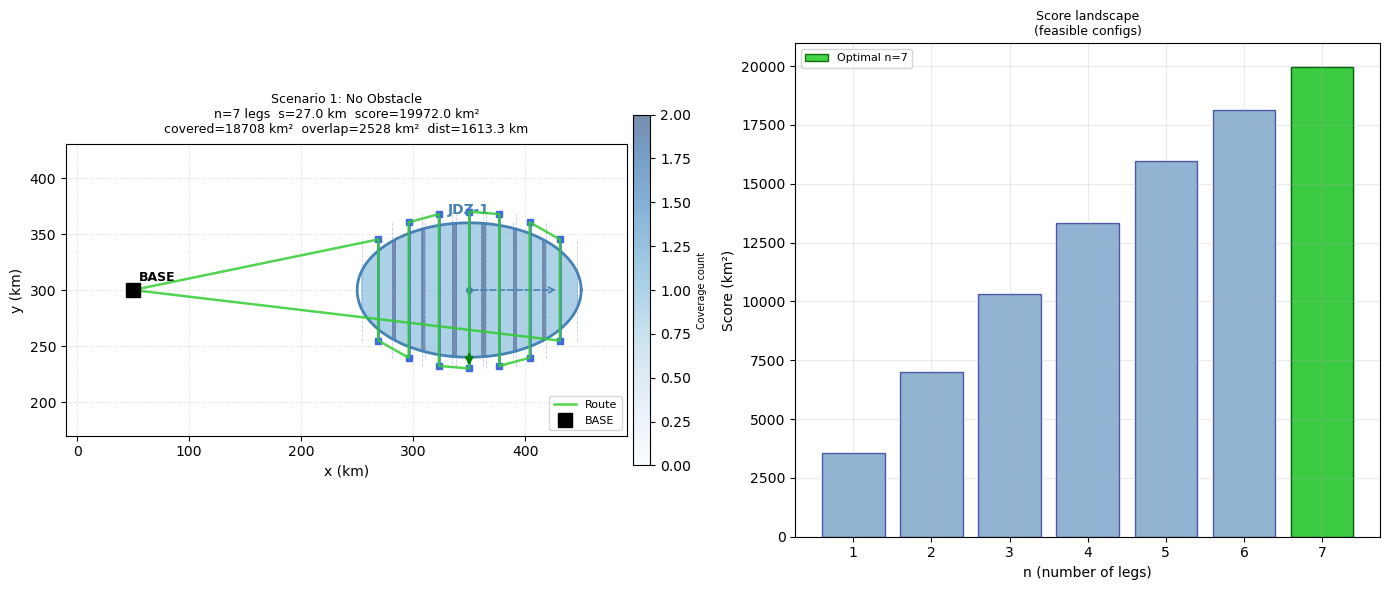

Figure saved.


In [10]:
# ─── Scenario 1 Plot ─────────────────────────────────────────────────────────

fig1, axes1 = plt.subplots(1, 2, figsize=(14, 6))
draw_elliptical_scenario(
    axes1, cell_s1, BASE, sol_s1, SENSOR_WIDTH, D_THRESH,
    title='Scenario 1: No Obstacle'
)
plt.tight_layout()
plt.savefig(
    '/home/yuanpei_cao/aerial-met-survey-optimizer/figures/unit_test_elliptical_s1.png',
    dpi=120, bbox_inches='tight'
)
plt.show()
print('Figure saved.')

In [11]:
# ─── Scenario 1 Global Optimality Proof ──────────────────────────────────────

prove_global_optimality(sol_s1, res_s1, BUDGET_S1)


GLOBAL OPTIMALITY PROOF — exhaustive enumeration
  n   s(km)   rev   top      score   cov km²  ovlp km²   dist km
--------------------------------------------------------------------------------
  7    27.0  True False   19972.00   18708.0    2528.0   1613.30  <-- GLOBAL OPTIMUM
  7    27.0  True  True   19972.00   18708.0    2528.0   1613.30
  7    27.0 False False   19972.00   18708.0    2528.0   1613.30
  7    27.0 False  True   19972.00   18708.0    2528.0   1613.30
  7    23.5 False False   19904.00   17524.0    4760.0   1631.71
  7    23.5 False  True   19904.00   17524.0    4760.0   1631.71
  7    23.5  True False   19904.00   17524.0    4760.0   1631.71
  7    23.5  True  True   19904.00   17524.0    4760.0   1631.71
  7    24.2 False False   19728.00   17772.0    3912.0   1628.77
  7    24.2  True False   19728.00   17772.0    3912.0   1628.77
  7    24.2  True  True   19728.00   17772.0    3912.0   1628.77
  7    24.2 False  True   19728.00   17772.0    3912.0   1628.77
  7 

---
## Scenario 2 — Large Obstacle Between BASE and Ellipse

**Setup (same ellipse, same scan params):**
- Obstacle: large rectangle at x ∈ [160, 248], y ∈ [240, 360]  
  Sits **directly across the transit corridor** BASE(50,300) → ellipse left edge(250,300).
- Budget = 2000 km (extra budget for detour)

**Effects:**
1. Transit BASE → first scan leg must detour around obstacle (+cost)
2. Return last scan leg → BASE also detours (+cost)
3. The **scan pattern itself is unchanged** — obstacle doesn't reach inside the ellipse
4. Optimizer may choose fewer legs (smaller n) so total distance stays within budget

**Expected:** n ≤ S1 optimal n or same n but tighter spacing; dist > S1 dist.  
**Proof:** exhaustive table confirms global optimum under tighter effective budget.

In [12]:
# ─── Scenario 2 Setup ────────────────────────────────────────────────────────

BUDGET_S2 = 2000.0  # km

obstacle_s2 = [
    [160.0, 240.0],
    [248.0, 240.0],
    [248.0, 360.0],
    [160.0, 360.0],
]

cell_s2 = EllipticalSupercell(
    center=np.array([350.0, 300.0]),
    a=100.0,
    b=60.0,
    phi=0.0,
    name='JDZ-1',
    obstacle=obstacle_s2,
)

print(f'Obstacle vertices (CCW): {[list(v) for v in cell_s2.obstacle]}')
print(f'  Width: {248-160} km,  Height: {360-240} km')
print(f'  Centroid: ({(160+248)/2:.0f}, {(240+360)/2:.0f})')
print(f'  Direct line BASE(50,300)→ellipse-left(250,300) passes through this obstacle.')
print(f'Budget: {BUDGET_S2} km')
print()

# Confirm obstacle blocks direct path
from math import isnan
blocked = segment_blocked(
    np.array([50., 300.]),
    np.array([250., 300.]),
    cell_s2.obstacle
)
print(f'Direct path BASE→ellipse-left blocked: {blocked}  (should be True)')

Obstacle vertices (CCW): [[np.float64(160.0), np.float64(240.0)], [np.float64(248.0), np.float64(240.0)], [np.float64(248.0), np.float64(360.0)], [np.float64(160.0), np.float64(360.0)]]
  Width: 88 km,  Height: 120 km
  Centroid: (204, 300)
  Direct line BASE(50,300)→ellipse-left(250,300) passes through this obstacle.
Budget: 2000.0 km

Direct path BASE→ellipse-left blocked: True  (should be True)


In [13]:
# ─── Scenario 2 Optimize ─────────────────────────────────────────────────────

print('Running optimizer for Scenario 2...')
sol_s2, res_s2 = optimize(
    cell_s2, BASE, BUDGET_S2, SENSOR_WIDTH, D_THRESH, S_MIN,
    n_max=N_MAX, n_s_steps=N_S_STEPS,
    overlap_bonus=OVERLAP_BONUS, grid_res=GRID_RES,
)
sol_s2['_all_results'] = res_s2

print(f'\n  n legs      : {sol_s2["n"]}')
print(f'  spacing s   : {sol_s2["s"]:.2f} km')
print(f'  reverse     : {sol_s2["reverse"]}')
print(f'  entry_top   : {sol_s2["entry_top"]}')
print(f'  covered area: {sol_s2["covered_area"]:.1f} km²  '
      f'({sol_s2["covered_area"]/(pi*cell_s2.a*cell_s2.b)*100:.1f}% of ellipse)')
print(f'  overlap area: {sol_s2["overlap_area"]:.1f} km²')
print(f'  score       : {sol_s2["score"]:.2f} km²')
print(f'  dist        : {sol_s2["dist"]:.2f} km  (budget {BUDGET_S2:.0f} km)')

Running optimizer for Scenario 2...


  Optimizer: 484 configs evaluated  (484 feasible).

  n legs      : 7
  spacing s   : 27.00 km
  reverse     : False
  entry_top   : False
  covered area: 18708.0 km²  (99.2% of ellipse)
  overlap area: 2528.0 km²
  score       : 19972.00 km²
  dist        : 1641.92 km  (budget 2000 km)


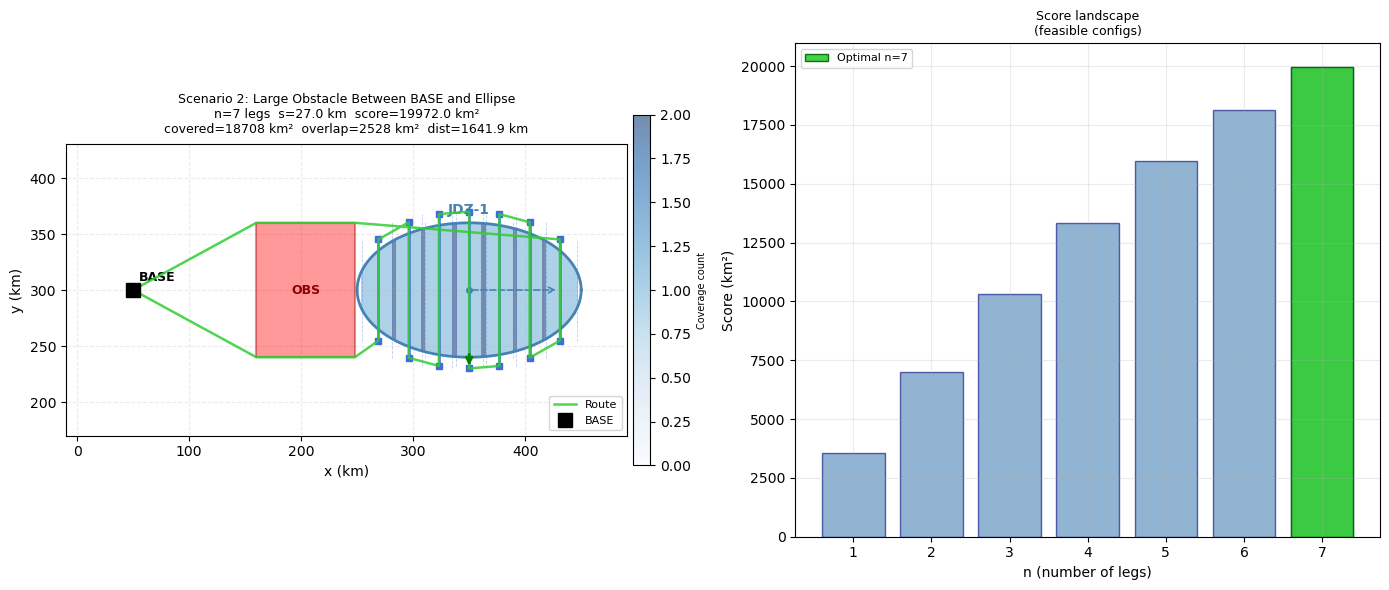

Figure saved.
Visual check: green route should detour around red obstacle on both inbound AND outbound legs.


In [14]:
# ─── Scenario 2 Plot ─────────────────────────────────────────────────────────

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
draw_elliptical_scenario(
    axes2, cell_s2, BASE, sol_s2, SENSOR_WIDTH, D_THRESH,
    title='Scenario 2: Large Obstacle Between BASE and Ellipse'
)
plt.tight_layout()
plt.savefig(
    '/home/yuanpei_cao/aerial-met-survey-optimizer/figures/unit_test_elliptical_s2.png',
    dpi=120, bbox_inches='tight'
)
plt.show()
print('Figure saved.')
print('Visual check: green route should detour around red obstacle on both inbound AND outbound legs.')

In [15]:
# ─── Scenario 2 Global Optimality Proof ──────────────────────────────────────

prove_global_optimality(sol_s2, res_s2, BUDGET_S2)


GLOBAL OPTIMALITY PROOF — exhaustive enumeration
  n   s(km)   rev   top      score   cov km²  ovlp km²   dist km
--------------------------------------------------------------------------------
  7    27.0 False False   19972.00   18708.0    2528.0   1641.92  <-- GLOBAL OPTIMUM
  7    27.0 False  True   19972.00   18708.0    2528.0   1641.92
  7    27.0  True False   19972.00   18708.0    2528.0   1641.92
  7    27.0  True  True   19972.00   18708.0    2528.0   1641.92
  7    23.5 False False   19904.00   17524.0    4760.0   1653.69
  7    23.5 False  True   19904.00   17524.0    4760.0   1653.69
  7    23.5  True False   19904.00   17524.0    4760.0   1653.69
  7    23.5  True  True   19904.00   17524.0    4760.0   1653.69
  7    24.2 False False   19728.00   17772.0    3912.0   1651.65
  7    24.2 False  True   19728.00   17772.0    3912.0   1651.65
  7    24.2  True False   19728.00   17772.0    3912.0   1651.65
  7    24.2  True  True   19728.00   17772.0    3912.0   1651.65
  7 

---
## Final Comparison

In [16]:
# ─── Final Comparison ────────────────────────────────────────────────────────

ellipse_area = pi * cell_s1.a * cell_s1.b

print('='*72)
print('ELLIPTICAL SUPERCELL UNIT TEST — SUMMARY')
print('='*72)
print(f'Ellipse area (π·a·b) = {ellipse_area:.1f} km²')
print()
print(f'{"":32} {"S1 (no obs)":>15} {"S2 (obstacle)":>15}')
print('-'*64)
rows = [
    ('Optimal n legs',         sol_s1['n'],                          sol_s2['n']),
    ('Optimal spacing (km)',   round(sol_s1['s'],1),                 round(sol_s2['s'],1)),
    ('Covered area (km²)',     round(sol_s1['covered_area'],1),      round(sol_s2['covered_area'],1)),
    ('Coverage % of ellipse',  round(sol_s1['covered_area']/ellipse_area*100,1),
                               round(sol_s2['covered_area']/ellipse_area*100,1)),
    ('Overlap area (km²)',     round(sol_s1['overlap_area'],1),      round(sol_s2['overlap_area'],1)),
    ('Score (km²)',            round(sol_s1['score'],2),             round(sol_s2['score'],2)),
    ('Route distance (km)',    round(sol_s1['dist'],1),              round(sol_s2['dist'],1)),
    ('Budget (km)',            BUDGET_S1,                            BUDGET_S2),
]
for label, v1, v2 in rows:
    print(f'{label:<32} {str(v1):>15} {str(v2):>15}')
print('='*72)
print()

# Sanity assertions
assert sol_s1['n'] >= 1,  'S1 must have ≥1 legs'
assert sol_s2['n'] >= 1,  'S2 must have ≥1 legs'
assert sol_s2['dist'] > sol_s1['dist'] - 0.1, \
    'S2 route should generally be ≥ S1 (obstacle adds distance)'
assert sol_s1['covered_area'] <= ellipse_area + 1, \
    'Covered area cannot exceed ellipse area'
assert sol_s2['covered_area'] <= ellipse_area + 1, \
    'Covered area cannot exceed ellipse area'

print('All sanity assertions passed.')
print()
print('Key insight: obstacle between BASE and ellipse adds detour distance to the')
print('transit legs (BASE→first scan leg and last scan leg→BASE) but does NOT')
print('change the scan pattern itself — the ellipse and its legs are unaffected.')
print(f'Obstacle distance overhead: {sol_s2["dist"] - sol_s1["dist"]:+.1f} km '
      f'(with {BUDGET_S2-BUDGET_S1:.0f} km extra budget)')

ELLIPTICAL SUPERCELL UNIT TEST — SUMMARY
Ellipse area (π·a·b) = 18849.6 km²

                                     S1 (no obs)   S2 (obstacle)
----------------------------------------------------------------
Optimal n legs                                 7               7
Optimal spacing (km)                        27.0            27.0
Covered area (km²)                       18708.0         18708.0
Coverage % of ellipse                       99.2            99.2
Overlap area (km²)                        2528.0          2528.0
Score (km²)                              19972.0         19972.0
Route distance (km)                       1613.3          1641.9
Budget (km)                               1800.0          2000.0

All sanity assertions passed.

Key insight: obstacle between BASE and ellipse adds detour distance to the
transit legs (BASE→first scan leg and last scan leg→BASE) but does NOT
change the scan pattern itself — the ellipse and its legs are unaffected.
Obstacle distance ove